In [1]:
!pip install -q tensorflow==2.0.0-beta1

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [2]:
!pip install -q statsmodels==0.9.0

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [3]:
!pip install -q scipy==1.2

tensorflow-serving-api 1.14.0 has requirement tensorflow~=1.14.0, but you'll have tensorflow 2.0.0b1 which is incompatible.
You are using pip version 10.0.1, however version 19.3.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [4]:
import os
import csv
import random
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import MinMaxScaler

dtypes = {
        'IsCanceled':                                    'float64',
        'LeadTime':                                          'float64',
        'StaysInWeekendNights':                                     'float64',
        'StaysInWeekNights':                                     'float64',
        'Adults':                            'float64',
        'Children':                            'float64',
        'Babies':                                  'float64',
        'Meal':                                    'category',
        'Country':                                               'category',
        'MarketSegment':                                    'category',
        'DistributionChannel':                                       'category',
        'IsRepeatedGuest':                               'float64',
        'PreviousCancellations':                                    'float64',
        'PreviousBookingsNotCanceled':                          'float64',
        'ReservedRoomType':                                             'category',
        'AssignedRoomType':                                            'category',
        'BookingChanges':                                                'float64',
        'DepositType':                                              'category',
        'Agent':                                              'category',
        'Company':                                 'category',
        'DaysInWaitingList':                                           'float64',
        'CustomerType':                                           'category',
        'ADR':                                          'float64',
        'RequiredCarParkingSpaces':                                      'float64',
        'TotalOfSpecialRequests':                                              'float64',
        'ReservationStatus':                                                'category'
        }

In [5]:
train_df = pd.read_csv('H1full.csv', dtype=dtypes, converters={'ArrivalDateWeekNumber': '{:0>2}'.format})
a=train_df.head()
b=train_df
b
c=b.sort_values(['ArrivalDateYear','ArrivalDateWeekNumber'], ascending=True)
c=pd.DataFrame(c)
c
type(c)

pandas.core.frame.DataFrame

In [6]:
from pandas import DataFrame  

df = DataFrame(c, columns= ['ArrivalDateYear', 'ArrivalDateWeekNumber']) 
df

,ArrivalDateYear,ArrivalDateWeekNumber
0,2015,27
1,2015,27
2,2015,27
3,2015,27
4,2015,27
5,2015,27
6,2015,27
7,2015,27
8,2015,27
9,2015,27


In [7]:
# https://datatofish.com/concatenate-values-python/

df1 = df['ArrivalDateYear'].map(str) + df['ArrivalDateWeekNumber'].map(str)
print (df1)
df1=pd.DataFrame(df1)

0        201527
1        201527
2        201527
3        201527
4        201527
5        201527
6        201527
7        201527
8        201527
9        201527
10       201527
11       201527
12       201527
13       201527
14       201527
15       201527
16       201527
17       201527
18       201527
19       201527
20       201527
21       201527
22       201527
23       201527
24       201527
25       201527
26       201527
27       201527
28       201527
29       201527
          ...  
40021    201735
40022    201735
40024    201735
40025    201735
40026    201735
40027    201735
40028    201735
40029    201735
40030    201735
40031    201735
40032    201735
40034    201735
40035    201735
40036    201735
40038    201735
40039    201735
40040    201735
40041    201735
40042    201735
40043    201735
40047    201735
40048    201735
40049    201735
40050    201735
40054    201735
40055    201735
40056    201735
40057    201735
40058    201735
40059    201735
Length: 40060, dtype: ob

In [8]:
df2 = DataFrame(c, columns= ['IsCanceled']) 
df2

,IsCanceled
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,1.0
9,1.0


In [9]:
type(df1)

pandas.core.frame.DataFrame

In [10]:
df3=pd.concat([df1, df2], axis = 1)
df3
df3.columns = ['FullDate', 'IsCanceled']

In [11]:
df3
df3.sort_values(['FullDate','IsCanceled'], ascending=True)

,FullDate,IsCanceled
0,201527,0.0
1,201527,0.0
2,201527,0.0
3,201527,0.0
4,201527,0.0
5,201527,0.0
6,201527,0.0
7,201527,0.0
11,201527,0.0
12,201527,0.0


In [12]:
df4 = df3.groupby('FullDate').agg(sum)
df4
df4.sort_values(['FullDate'], ascending=True)

,IsCanceled
FullDate,
201527,41.0
201528,48.0
201529,87.0
201530,74.0
201531,101.0
201532,68.0
201533,96.0
201534,69.0
201535,88.0


In [13]:
tseries=df4['IsCanceled']
tseries

FullDate
201527     41.0
201528     48.0
201529     87.0
201530     74.0
201531    101.0
201532     68.0
201533     96.0
201534     69.0
201535     88.0
201536    148.0
201537     76.0
201538    186.0
201539    123.0
201540     91.0
201541    198.0
201542     16.0
201543     94.0
201544     44.0
201545     45.0
201546     54.0
201547     63.0
201548     18.0
201549    127.0
201550     24.0
201551     37.0
201552     79.0
201553     43.0
201601     35.0
201602     40.0
201603     14.0
          ...  
201706     91.0
201707     96.0
201708    128.0
201709     77.0
201710    126.0
201711     83.0
201712     49.0
201713    105.0
201714    109.0
201715    179.0
201716    104.0
201717    106.0
201718    167.0
201719    106.0
201720     79.0
201721    130.0
201722    202.0
201723    117.0
201724    152.0
201725    131.0
201726    161.0
201727    131.0
201728    139.0
201729    150.0
201730    157.0
201731    173.0
201732    140.0
201733    182.0
201734    143.0
201735    100.0
Name: IsCancele

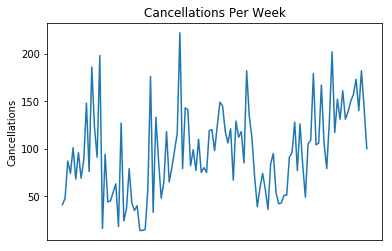

In [14]:
import matplotlib.pyplot as plt
plt.plot(tseries)
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
plt.ylabel('Cancellations')
plt.title("Cancellations Per Week")
plt.show()

In [15]:
df=pd.DataFrame(tseries)
df

,IsCanceled
FullDate,
201527,41.0
201528,48.0
201529,87.0
201530,74.0
201531,101.0
201532,68.0
201533,96.0
201534,69.0
201535,88.0


In [16]:
df = df[:100]

In [17]:
df

,IsCanceled
FullDate,
201527,41.0
201528,48.0
201529,87.0
201530,74.0
201531,101.0
201532,68.0
201533,96.0
201534,69.0
201535,88.0


In [18]:
# Form dataset matrix
def create_dataset(df, previous=1):
    dataX, dataY = [], []
    for i in range(len(df)-previous-1):
        a = df[i:(i+previous), 0]
        dataX.append(a)
        dataY.append(df[i + previous, 0])
    return np.array(dataX), np.array(dataY)

In [19]:
df

,IsCanceled
FullDate,
201527,41.0
201528,48.0
201529,87.0
201530,74.0
201531,101.0
201532,68.0
201533,96.0
201534,69.0
201535,88.0


In [20]:
# normalize dataset with MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
df = scaler.fit_transform(df)
df

array([[0.12980769],
       [0.16346154],
       [0.35096154],
       [0.28846154],
       [0.41826923],
       [0.25961538],
       [0.39423077],
       [0.26442308],
       [0.35576923],
       [0.64423077],
       [0.29807692],
       [0.82692308],
       [0.52403846],
       [0.37019231],
       [0.88461538],
       [0.00961538],
       [0.38461538],
       [0.14423077],
       [0.14903846],
       [0.19230769],
       [0.23557692],
       [0.01923077],
       [0.54326923],
       [0.04807692],
       [0.11057692],
       [0.3125    ],
       [0.13942308],
       [0.10096154],
       [0.125     ],
       [0.        ],
       [0.        ],
       [0.00480769],
       [0.20673077],
       [0.77884615],
       [0.09134615],
       [0.57211538],
       [0.35576923],
       [0.16346154],
       [0.24519231],
       [0.5       ],
       [0.24519231],
       [0.31730769],
       [0.40384615],
       [0.49038462],
       [1.        ],
       [0.3125    ],
       [0.62019231],
       [0.610

In [21]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

# Training and Validation data partition
train_size = int(len(df) * 0.8)
val_size = len(df) - train_size
train, val = df[0:train_size,:], df[train_size:len(df),:]

# Number of previous
previous = 5
X_train, Y_train = create_dataset(train, previous)
X_val, Y_val = create_dataset(val, previous)

In [22]:
X_train

array([[0.12980769, 0.16346154, 0.35096154, 0.28846154, 0.41826923],
       [0.16346154, 0.35096154, 0.28846154, 0.41826923, 0.25961538],
       [0.35096154, 0.28846154, 0.41826923, 0.25961538, 0.39423077],
       [0.28846154, 0.41826923, 0.25961538, 0.39423077, 0.26442308],
       [0.41826923, 0.25961538, 0.39423077, 0.26442308, 0.35576923],
       [0.25961538, 0.39423077, 0.26442308, 0.35576923, 0.64423077],
       [0.39423077, 0.26442308, 0.35576923, 0.64423077, 0.29807692],
       [0.26442308, 0.35576923, 0.64423077, 0.29807692, 0.82692308],
       [0.35576923, 0.64423077, 0.29807692, 0.82692308, 0.52403846],
       [0.64423077, 0.29807692, 0.82692308, 0.52403846, 0.37019231],
       [0.29807692, 0.82692308, 0.52403846, 0.37019231, 0.88461538],
       [0.82692308, 0.52403846, 0.37019231, 0.88461538, 0.00961538],
       [0.52403846, 0.37019231, 0.88461538, 0.00961538, 0.38461538],
       [0.37019231, 0.88461538, 0.00961538, 0.38461538, 0.14423077],
       [0.88461538, 0.00961538, 0.

In [23]:
Y_train

array([0.25961538, 0.39423077, 0.26442308, 0.35576923, 0.64423077,
       0.29807692, 0.82692308, 0.52403846, 0.37019231, 0.88461538,
       0.00961538, 0.38461538, 0.14423077, 0.14903846, 0.19230769,
       0.23557692, 0.01923077, 0.54326923, 0.04807692, 0.11057692,
       0.3125    , 0.13942308, 0.10096154, 0.125     , 0.        ,
       0.        , 0.00480769, 0.20673077, 0.77884615, 0.09134615,
       0.57211538, 0.35576923, 0.16346154, 0.24519231, 0.5       ,
       0.24519231, 0.31730769, 0.40384615, 0.49038462, 1.        ,
       0.3125    , 0.62019231, 0.61057692, 0.32692308, 0.40865385,
       0.30288462, 0.46153846, 0.29326923, 0.31730769, 0.29326923,
       0.50480769, 0.50961538, 0.40384615, 0.52884615, 0.64903846,
       0.62980769, 0.5       , 0.44230769, 0.51442308, 0.25480769,
       0.55288462, 0.47115385, 0.5       , 0.34134615, 0.80769231,
       0.57692308, 0.46634615, 0.26923077, 0.12019231, 0.21634615,
       0.28846154, 0.20673077, 0.10576923, 0.33653846])

In [24]:
# reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))

# Generate LSTM network
model = tf.keras.Sequential()
model.add(LSTM(4, input_shape=(1, previous)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, Y_train, epochs=150, batch_size=1, verbose=2)

Train on 74 samples
Epoch 1/150
74/74 - 1s - loss: 0.1798
Epoch 2/150
74/74 - 0s - loss: 0.1075
Epoch 3/150
74/74 - 0s - loss: 0.0650
Epoch 4/150
74/74 - 0s - loss: 0.0472
Epoch 5/150
74/74 - 0s - loss: 0.0432
Epoch 6/150
74/74 - 0s - loss: 0.0425
Epoch 7/150
74/74 - 0s - loss: 0.0420
Epoch 8/150
74/74 - 0s - loss: 0.0417
Epoch 9/150
74/74 - 0s - loss: 0.0415
Epoch 10/150
74/74 - 0s - loss: 0.0412
Epoch 11/150
74/74 - 0s - loss: 0.0409
Epoch 12/150
74/74 - 0s - loss: 0.0410
Epoch 13/150
74/74 - 0s - loss: 0.0411
Epoch 14/150
74/74 - 0s - loss: 0.0405
Epoch 15/150
74/74 - 0s - loss: 0.0404
Epoch 16/150
74/74 - 0s - loss: 0.0400
Epoch 17/150
74/74 - 0s - loss: 0.0396
Epoch 18/150
74/74 - 0s - loss: 0.0399
Epoch 19/150
74/74 - 0s - loss: 0.0396
Epoch 20/150
74/74 - 0s - loss: 0.0396
Epoch 21/150
74/74 - 0s - loss: 0.0395
Epoch 22/150
74/74 - 0s - loss: 0.0390
Epoch 23/150
74/74 - 0s - loss: 0.0388
Epoch 24/150
74/74 - 0s - loss: 0.0386
Epoch 25/150
74/74 - 0s - loss: 0.0385
Epoch 26/150
7

In [25]:
# Generate predictions
trainpred = model.predict(X_train)
valpred = model.predict(X_val)

In [26]:
trainpred

array([[0.3886667 ],
       [0.38468766],
       [0.38049227],
       [0.35512948],
       [0.37319118],
       [0.34788018],
       [0.5091051 ],
       [0.42736638],
       [0.46028358],
       [0.57914805],
       [0.2778778 ],
       [0.43296242],
       [0.33623654],
       [0.15571275],
       [0.18323472],
       [0.23072222],
       [0.27238628],
       [0.2818008 ],
       [0.24703717],
       [0.31971213],
       [0.27758583],
       [0.15796581],
       [0.2625826 ],
       [0.29421782],
       [0.22305018],
       [0.20015311],
       [0.18698773],
       [0.16617042],
       [0.19834784],
       [0.2550425 ],
       [0.5320327 ],
       [0.3565666 ],
       [0.2481145 ],
       [0.3448734 ],
       [0.26497135],
       [0.30073088],
       [0.4196759 ],
       [0.3901481 ],
       [0.31091407],
       [0.42534256],
       [0.41752294],
       [0.6738583 ],
       [0.51073605],
       [0.2978662 ],
       [0.49503094],
       [0.4069573 ],
       [0.34705243],
       [0.393

In [27]:
valpred

array([[0.27095047],
       [0.29964837],
       [0.36799905],
       [0.44207013],
       [0.47080767],
       [0.4261924 ],
       [0.40169382],
       [0.38402903],
       [0.2815157 ],
       [0.3679741 ],
       [0.49824536],
       [0.572907  ],
       [0.5345455 ],
       [0.34178984]], dtype=float32)

In [28]:
# Convert predictions back to normal values
trainpred = scaler.inverse_transform(trainpred)
Y_train = scaler.inverse_transform([Y_train])
valpred = scaler.inverse_transform(valpred)
Y_val = scaler.inverse_transform([Y_val])
predictions = valpred

In [29]:
import math
from sklearn.metrics import mean_squared_error

# calculate RMSE
trainScore = math.sqrt(mean_squared_error(Y_train[0], trainpred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
valScore = math.sqrt(mean_squared_error(Y_val[0], valpred[:,0]))
print('Validation Score: %.2f RMSE' % (valScore))

Train Score: 37.48 RMSE
Validation Score: 36.24 RMSE


In [30]:
# Train predictions
trainpredPlot = np.empty_like(df)
trainpredPlot[:, :] = np.nan
trainpredPlot[previous:len(trainpred)+previous, :] = trainpred

In [31]:
# Validation predictions
valpredPlot = np.empty_like(df)
valpredPlot[:, :] = np.nan
valpredPlot[len(trainpred)+(previous*2)+1:len(df)-1, :] = valpred

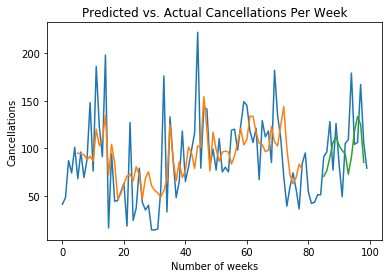

In [32]:
# Plot all predictions
inversetransform, =plt.plot(scaler.inverse_transform(df))
trainpred, =plt.plot(trainpredPlot)
valpred, =plt.plot(valpredPlot)
plt.xlabel('Number of weeks')
plt.ylabel('Cancellations')
plt.title("Predicted vs. Actual Cancellations Per Week")
plt.show()

In [33]:
Y_val=Y_val.reshape(-1)
Y_val.shape
Y_val=pd.Series(Y_val)

In [34]:
Y_val

0      91.0
1      96.0
2     128.0
3      77.0
4     126.0
5      83.0
6      49.0
7     105.0
8     109.0
9     179.0
10    104.0
11    106.0
12    167.0
13    106.0
dtype: float64

In [35]:
predictions=predictions.reshape(-1)
predictions.shape
predictions=pd.Series(predictions)

In [36]:
predictions

0      70.357697
1      76.326859
2      90.543800
3     105.950592
4     111.928001
5     102.648018
6      97.552315
7      93.878036
8      72.555260
9      90.538612
10    117.635040
11    133.164658
12    125.185463
13     85.092285
dtype: float32

In [37]:
import numpy as np

def mda(actual: np.ndarray, predicted: np.ndarray):
    """ Mean Directional Accuracy """
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [38]:
mda(Y_val, predictions)

0.8571428571428571

In [39]:
# https://machinelearningmastery.com/time-series-forecasting-performance-measures-with-python/

from sklearn.metrics import mean_squared_error
from math import sqrt
mse = mean_squared_error(Y_val, predictions)
rmse = sqrt(mse)
print('RMSE: %f' % rmse)

RMSE: 36.235725


In [40]:
forecast_error = (predictions-Y_val)
forecast_error

0    -20.642303
1    -19.673141
2    -37.456200
3     28.950592
4    -14.071999
5     19.648018
6     48.552315
7    -11.121964
8    -36.444740
9    -88.461388
10    13.635040
11    27.164658
12   -41.814537
13   -20.907715
dtype: float64

In [41]:
mean_forecast_error = np.mean(forecast_error)
mean_forecast_error

-10.903097425188337

In [42]:
X_train

array([[[0.12980769, 0.16346154, 0.35096154, 0.28846154, 0.41826923]],

       [[0.16346154, 0.35096154, 0.28846154, 0.41826923, 0.25961538]],

       [[0.35096154, 0.28846154, 0.41826923, 0.25961538, 0.39423077]],

       [[0.28846154, 0.41826923, 0.25961538, 0.39423077, 0.26442308]],

       [[0.41826923, 0.25961538, 0.39423077, 0.26442308, 0.35576923]],

       [[0.25961538, 0.39423077, 0.26442308, 0.35576923, 0.64423077]],

       [[0.39423077, 0.26442308, 0.35576923, 0.64423077, 0.29807692]],

       [[0.26442308, 0.35576923, 0.64423077, 0.29807692, 0.82692308]],

       [[0.35576923, 0.64423077, 0.29807692, 0.82692308, 0.52403846]],

       [[0.64423077, 0.29807692, 0.82692308, 0.52403846, 0.37019231]],

       [[0.29807692, 0.82692308, 0.52403846, 0.37019231, 0.88461538]],

       [[0.82692308, 0.52403846, 0.37019231, 0.88461538, 0.00961538]],

       [[0.52403846, 0.37019231, 0.88461538, 0.00961538, 0.38461538]],

       [[0.37019231, 0.88461538, 0.00961538, 0.38461538, 0.14423

In [43]:
# Test (unseen) predictions
# (t) and (t-5)
Xnew = np.array([[130,202,117,152,131],[202,117,152,131,161],[117,152,131,161,131],[152,131,161,131,139],[131,161,131,139,150],[161,131,139,150,157],[131,139,150,157,173],[139,150,157,173,140],[150,157,173,140,182],[157,173,140,182,143]])

In [44]:
Xnew

array([[130, 202, 117, 152, 131],
       [202, 117, 152, 131, 161],
       [117, 152, 131, 161, 131],
       [152, 131, 161, 131, 139],
       [131, 161, 131, 139, 150],
       [161, 131, 139, 150, 157],
       [131, 139, 150, 157, 173],
       [139, 150, 157, 173, 140],
       [150, 157, 173, 140, 182],
       [157, 173, 140, 182, 143]])

In [45]:
Xnew = scaler.fit_transform(Xnew)
Xnew
Xnewformat = np.reshape(Xnew, (Xnew.shape[0], 1, Xnew.shape[1]))
ynew=model.predict(Xnewformat)

In [46]:
Xnew.shape

(10, 5)

In [47]:
ynew

array([[0.11756782],
       [0.27770886],
       [0.39859068],
       [0.27660903],
       [0.24783161],
       [0.4462832 ],
       [0.51740026],
       [0.6780623 ],
       [0.418799  ],
       [0.56597257]], dtype=float32)

In [48]:
type(ynew)

numpy.ndarray

In [49]:
ynew.shape

(10, 1)

In [50]:
actual = np.array([[161,131,139,150,157,173,140,182,143,100]])

In [51]:
actual=actual.reshape(10,-1)
actual.shape

(10, 1)

In [52]:
actual

array([[161],
       [131],
       [139],
       [150],
       [157],
       [173],
       [140],
       [182],
       [143],
       [100]])

In [53]:
ynew=ynew.reshape(-1)
actual=actual.reshape(-1)
actualpd=pd.Series(actual)

In [54]:
np.min(df)

0.0

In [55]:
ynew

array([0.11756782, 0.27770886, 0.39859068, 0.27660903, 0.24783161,
       0.4462832 , 0.51740026, 0.6780623 , 0.418799  , 0.56597257],
      dtype=float32)

In [56]:
maxcancel=np.max(tseries)

In [57]:
mincancel=np.min(tseries)

In [58]:
ynew = ynew * np.abs(maxcancel-mincancel) + np.min(tseries)
ynewpd=pd.Series(ynew)

In [59]:
actualpd

0    161
1    131
2    139
3    150
4    157
5    173
6    140
7    182
8    143
9    100
dtype: int64

In [60]:
ynewpd

0     38.454109
1     71.763443
2     96.906860
3     71.534683
4     65.548981
5    106.826904
6    121.619255
7    155.036957
8    101.110191
9    131.722290
dtype: float32

In [61]:
mda(actualpd, ynewpd)

0.8

In [62]:
mse = mean_squared_error(actualpd, ynewpd)
rmse = sqrt(mse)
print('RMSE: %f' % rmse)

RMSE: 65.592064


In [63]:
forecast_error = (ynewpd-actualpd)
forecast_error

0   -122.545891
1    -59.236557
2    -42.093140
3    -78.465317
4    -91.451019
5    -66.173096
6    -18.380745
7    -26.963043
8    -41.889809
9     31.722290
dtype: float64

In [64]:
mean_forecast_error = np.mean(forecast_error)
mean_forecast_error

-51.54763259887695

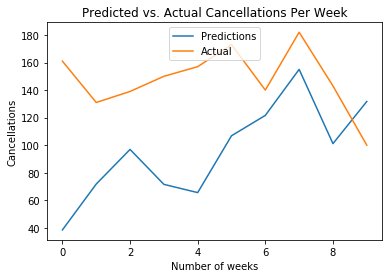

In [65]:
predictons, =plt.plot(ynewpd, label='Predictions')
actual, =plt.plot(actualpd, label='Actual')
plt.xlabel('Number of weeks')
plt.ylabel('Cancellations')
plt.title("Predicted vs. Actual Cancellations Per Week")
plt.legend(loc = 'upper center')
plt.show()